In [1]:
!pip install ollama

In [2]:
import ollama

response = ollama.chat(
    model="llama3.2",
    messages=[{"role": "user", "content": "Hello"}]
)

print(response['message']['content'])

How can I assist you today?


✅ PDF Loaded Successfully!
📄 File: D:\LENOVO\Download\ARCS Data sample.pdf
📊 Total Pages: 407

👀 Preview Page 0


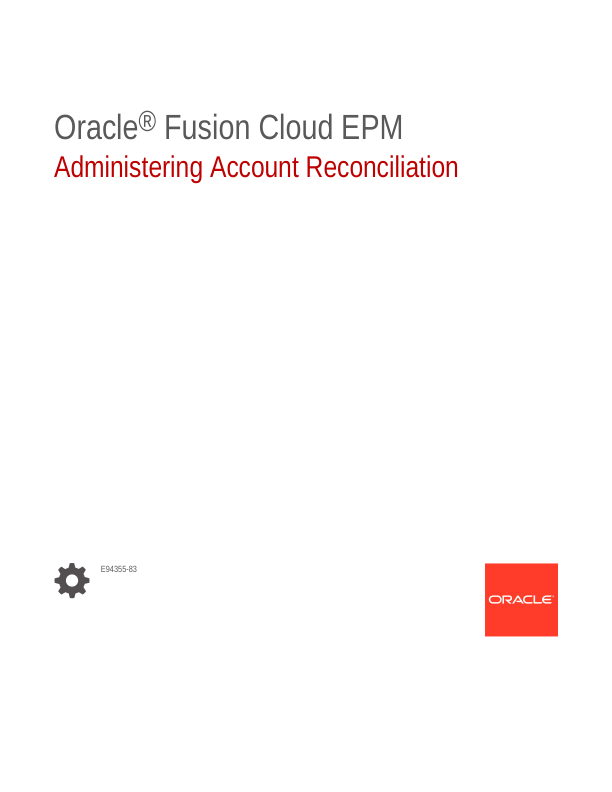


👀 Preview Page 1


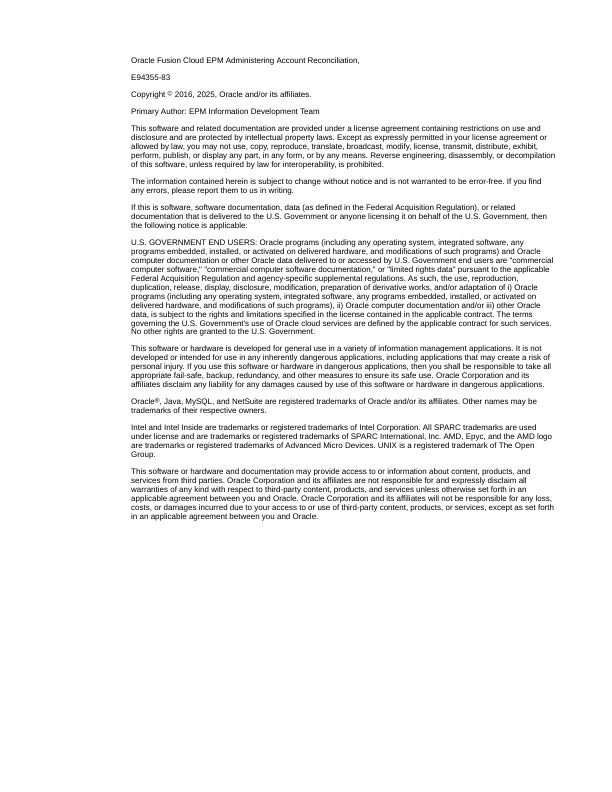


🖼️ Total Extracted Images: 255


In [3]:
import fitz
import os
from IPython.display import display, Image as IPImage

file_path = r"D:\LENOVO\Download\ARCS Data sample.pdf"

doc = fitz.open(file_path)

print("✅ PDF Loaded Successfully!")
print("📄 File:", file_path)
print("📊 Total Pages:", len(doc))

texts = []
image_paths = []

img_folder = "D:\LENOVO\Download\Images"
os.makedirs(img_folder, exist_ok=True)

# 🔹 Extract + Preview
for page_num in range(len(doc)):
    page = doc[page_num]
    
    # Extract text
    texts.append(page.get_text())
    
    # Show first 2 pages preview
    if page_num < 2:
        pix = page.get_pixmap()
        preview_path = f"preview_{page_num}.png"
        pix.save(preview_path)
        
        print(f"\n👀 Preview Page {page_num}")
        display(IPImage(filename=preview_path))
    
    # Extract images
    for i, img in enumerate(page.get_images(full=True)):
        xref = img[0]
        base = doc.extract_image(xref)
        
        path = f"{img_folder}/p{page_num}_{i}.png"
        
        with open(path, "wb") as f:
            f.write(base["image"])
        
        image_paths.append((page_num, path))

print("\n🖼️ Total Extracted Images:", len(image_paths))

In [4]:
chunks = []
chunk_page_map = []

for i, text in enumerate(texts):
    for chunk in text.split("\n\n"):
        if len(chunk) > 100:
            chunks.append(chunk)
            chunk_page_map.append(i)

# ✅ Chunk count
print("🧩 Total Chunks:", len(chunks))

🧩 Total Chunks: 406


In [5]:
from collections import Counter

page_counts = Counter(chunk_page_map)
print("📊 Chunks per page (sample):", dict(list(page_counts.items())[:5]))

📊 Chunks per page (sample): {1: 1, 2: 1, 3: 1, 4: 1, 5: 1}


In [6]:
print("\n🔍 Sample Chunks:\n")
for i in range(3):
    print(f"Chunk {i}:\n", chunks[i][:200], "\n")


🔍 Sample Chunks:

Chunk 0:
 Oracle Fusion Cloud EPM Administering Account Reconciliation,
E94355-83
Copyright © 2016, 2025, Oracle and/or its affiliates.
Primary Author: EPM Information Development Team
This software and related 

Chunk 1:
 Contents
 
Documentation Accessibility
 
Documentation Feedback
1   
Creating and Running an EPM Center of Excellence
2   
Learning About Account Reconciliation
Overview of Reconciliation Compliance
1 

Chunk 2:
 Application
18
Reconciliation Activity
20
Overview of Reconciliation Compliance Configuration
21
Periods
24
Services
25
Tools
26
Appearance
27
Announcements
27
Service Activity Report
27
Audit Report
 



In [7]:
avg_len = sum(len(c) for c in chunks) / len(chunks)
print("📏 Avg Chunk Length:", int(avg_len))

📏 Avg Chunk Length: 1847


In [7]:
import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

In [8]:
from sentence_transformers import SentenceTransformer
from PIL import Image
import numpy as np

text_model = SentenceTransformer('all-MiniLM-L6-v2')
clip_model = SentenceTransformer('clip-ViT-B-32')

# Text embeddings
text_embeddings = text_model.encode(chunks)

# Image embeddings
image_embeddings = []
image_files = []

for page, path in image_paths:
    try:
        img = Image.open(path).convert("RGB")
        emb = clip_model.encode(img)
        image_embeddings.append(emb)
        image_files.append(path)
    except:
        continue

image_embeddings = np.array(image_embeddings)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: C:\Users\LENOVO\.cache\huggingface\hub\models--sentence-transformers--clip-ViT-B-32\snapshots\327ab6726d33c0e22f920c83f2ff9e4bd38ca37f\0_CLIPModel
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [9]:
import faiss

text_index = faiss.IndexFlatL2(len(text_embeddings[0]))
text_index.add(np.array(text_embeddings))

image_index = faiss.IndexFlatL2(len(image_embeddings[0]))
image_index.add(image_embeddings)

In [10]:
print(type(image_files[0]))
print(image_files[0])

<class 'str'>
D:\LENOVO\Download\Images/p17_0.png


In [11]:
import ollama
import os
from IPython.display import display, Image as IPImage

def chatbot():
    print("🤖 Local Multimodal RAG Chatbot\n")

    while True:
        query = input("🧑 Ask: ")

        if query.lower() == "exit":
            break

        # 🔹 TEXT SEARCH — get more chunks for better context
        q_emb = text_model.encode([query], normalize_embeddings=True)
        D, I = text_index.search(np.array(q_emb), k=10)

        retrieved_chunks = [chunks[i] for i in I[0]]
        context = "\n\n".join(retrieved_chunks)

        # 🔹 RELEVANCE CHECK
        best_score = float(D[0][0])
        print(f"[DEBUG] Best text score: {best_score:.3f}")

        if best_score < 0.25:
            print("\n❌ This question is not related to the document.\n")
            print("=" * 60)
            continue

        # 🔹 LLM ANSWER — detailed prompt
        response = ollama.chat(
            model="llama3.2",
            messages=[
                {
                    "role": "system",
                    "content": """You are a PDF document assistant. Follow these rules:
1. Answer ONLY from the context provided. 
2. If the answer is NOT in the context, say: "Not available in document."
3. Never use your own knowledge.
4. Give DETAILED and COMPLETE answers — include all relevant steps, details, and explanations found in the context.
5. If the context contains step-by-step instructions, list ALL the steps."""
                },
                {
                    "role": "user",
                    "content": f"""Context:
{context}

Question: {query}

Instructions: Give a detailed and complete answer using ALL relevant information from the context above. Include every step and detail mentioned. If the answer is not in the context, say "Not available in document." only."""
                }
            ]
        )

        answer = response['message']['content']
        print("\n📄 Answer:\n")
        print(answer)

        # 🔹 IMAGE SEARCH — with proper normalization
        if "not available" not in answer.lower():
            q_img = clip_model.encode([query], normalize_embeddings=True)

            # Normalize the query embedding manually to be safe
            q_img_norm = q_img / np.linalg.norm(q_img, axis=1, keepdims=True)

            D_img, I_img = image_index.search(np.array(q_img_norm), k=10)

            # Check if scores are normalized (0-1) or raw
            max_score = float(D_img[0][0])
            min_score = float(D_img[0][-1])
            print(f"[DEBUG] Image scores range: {min_score:.3f} to {max_score:.3f}")

            # Set threshold based on score range
            if max_score > 2.0:
                # Scores are NOT normalized — use relative threshold
                threshold = max_score * 0.85  # top 85% of best score
            else:
                # Scores are normalized (0-1)
                threshold = 0.20

            print(f"[DEBUG] Image threshold: {threshold:.3f}")

            print("\n🖼️ Images:\n")
            shown = 0

            for score, idx in zip(D_img[0], I_img[0]):
                if idx < len(image_files):
                    path = image_files[idx]

                    if score >= threshold and os.path.exists(path):
                        print(f"  [Score: {score:.3f}] {os.path.basename(path)}")
                        display(IPImage(filename=path))
                        shown += 1
                        if shown >= 3:
                            break

            if shown == 0:
                # Show top 1 image as fallback
                idx = int(I_img[0][0])
                if idx < len(image_files):
                    path = image_files[idx]
                    if os.path.exists(path):
                        print(f"  [Best match - Score: {D_img[0][0]:.3f}] {os.path.basename(path)}")
                        display(IPImage(filename=path))
                        shown = 1

            if shown == 0:
                print("No relevant images found.")

        print("\n" + "=" * 60)



🤖 Local Multimodal RAG Chatbot



🧑 Ask:  what is the capital of india?


[DEBUG] Best text score: 1.752

📄 Answer:

I don't have any information about the capital of India in the provided context. The text appears to be a guide for administering Account Reconciliation Cloud, covering topics such as creating applications, setting attributes, and managing users.

However, I can suggest some possible steps to find the answer:

1. Check external sources: You can search online or consult a reliable encyclopedia or Wikipedia for information on the capital of India.
2. Look for additional context: If you have access to more information about Account Reconciliation Cloud or its related applications, you may be able to find the answer there.

But based on the provided text, I must answer:

Not available in document.



🧑 Ask:  give me one Example of Transaction Matching Dashboard?


[DEBUG] Best text score: 0.680

📄 Answer:

To create a Transaction Matching dashboard, follow these steps:

1. From Home, select Dashboards, then Custom.

2. The existing custom dashboards are displayed.

3. Click the Add icon to create a new dashboard.

A new dashboard is created with a default name and is opened in a new tab.

4. Click Settings for the dashboard, to update the dashboard properties.
• Set the Name to Transaction Matching Dashboard
• Set the Layout to Vertical.
• Select Vertical Split.

5. Click Settings for the view on the left and create a chart view. 
  To create this view:
    • First select Chart View in the list of available views.
    • Then, select Match Types With High Unmatched Transactions (the example chart view used).
    • Finally, click the Apply button to apply these settings.

6. Click Settings for the view on the right and create a chart view. 
  To create this view:
    • First select List or Pivot View in the list of available views.
    • Then, sel

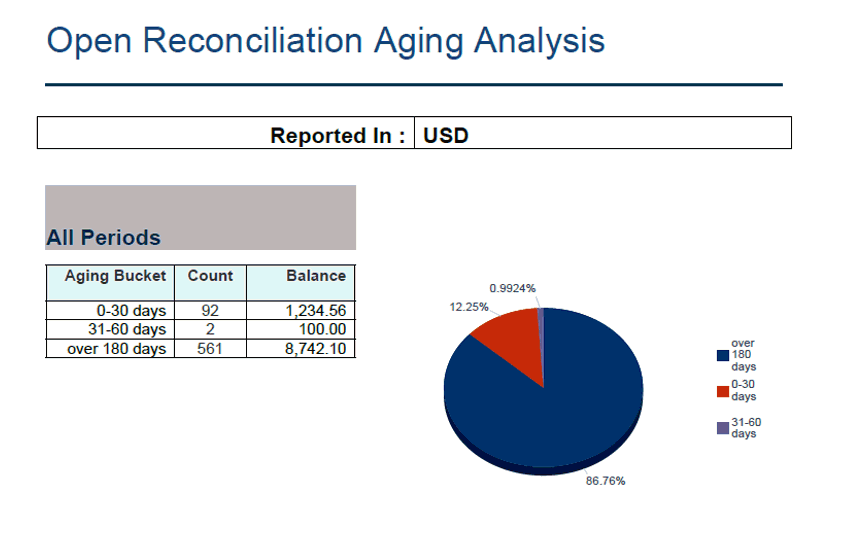

  [Score: 63.738] p315_0.png


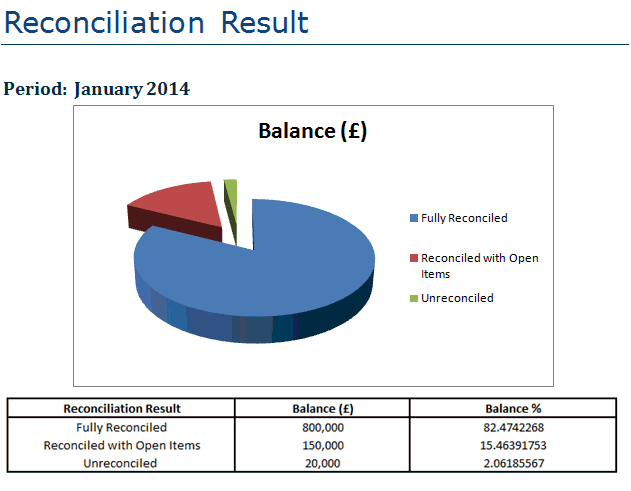

  [Score: 64.506] p81_1.png


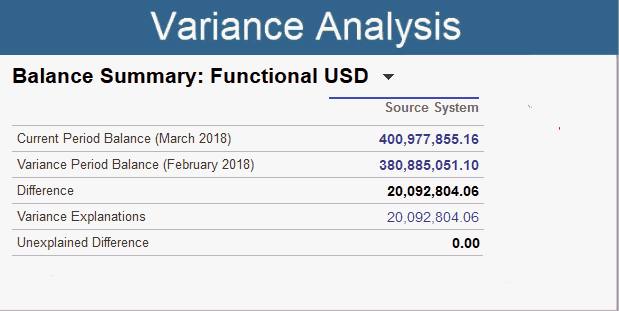

🧑 Ask:  exit


In [12]:
chatbot()

In [ ]:
# 1.11 AM  (how to add a parameter) end time -  1.16 AM

In [ ]:
# 8.45 AM (what is the capital of india) end time - 9.08 AM  
# second question - 9.10 AM end time 9.42 AM.

In [ ]:
#CHATGPT CODE:




import ollama
import numpy as np
from IPython.display import display, Image as IPImage

def chatbot():
    print("🤖 Local Multimodal RAG Chatbot\n")
    
    while True:
        query = input("🧑 Ask: ").strip()
        
        if query.lower() == "exit":
            break
        
        if not query:
            print("⚠️ Enter valid question")
            continue
        
        # 🔹 TEXT SEARCH (FIXED)
        q_emb = text_model.encode([query], normalize_embeddings=True)
        D, I = text_index.search(np.array(q_emb), k=3)

        top_score = D[0][0]

        # ✅ RELEVANCE CHECK (IMPORTANT)
        if top_score < 0.3:
            print("\n❌ Question not related to PDF\n")
            continue

        retrieved_chunks = [chunks[i] for i in I[0]]
        retrieved_pages = [chunk_page_map[i] for i in I[0]]

        context = "\n\n".join(retrieved_chunks)

        # 🔹 LLM ANSWER
        response = ollama.chat(
            model="llama3.2",
            messages=[
                {
                    "role": "system",
                    "content": (
                        "Answer ONLY from the given context.\n"
                        "If answer not present, say: Not available in document.\n"
                        "Give clear and short answer."
                    )
                },
                {
                    "role": "user",
                    "content": f"Context:\n{context}\n\nQuestion: {query}"
                }
            ]
        )
        
        print("\n📄 Answer:\n")
        print(response['message']['content'])

        # 🔹 IMAGE SEARCH (FIXED 🔥)
        q_img = clip_model.encode([query], normalize_embeddings=True)
        D_img, I_img = image_index.search(np.array(q_img), k=5)

        print("\n🖼️ Relevant Images:\n")

        shown = 0

        for score, idx in zip(D_img[0], I_img[0]):

            page, path = image_files[idx]

            # ✅ FILTER 1: Score threshold
            if score < 0.25:
                continue

            # ✅ FILTER 2: Page match (VERY IMPORTANT)
            if page not in retrieved_pages:
                continue

            display(IPImage(filename=path))
            print(f"📌 Page: {page} | Score: {round(score, 2)}")

            shown += 1

            if shown >= 3:
                break

        if shown == 0:
            print("⚠️ No relevant images found")

        print("\n📄 Source Pages:", list(set(retrieved_pages)))
        print("\n" + "="*60)

In [ ]:
#Claude ai working code

import ollama
import os
from IPython.display import display, Image as IPImage

def chatbot():
    print("🤖 Local Multimodal RAG Chatbot\n")

    while True:
        query = input("🧑 Ask: ")

        if query.lower() == "exit":
            break

        # 🔹 TEXT SEARCH
        q_emb = text_model.encode([query], normalize_embeddings=True)
        D, I = text_index.search(np.array(q_emb), k=5)

        retrieved_chunks = [chunks[i] for i in I[0]]
        context = "\n".join(retrieved_chunks)

        # 🔹 RELEVANCE CHECK
        best_score = float(D[0][0])

        if best_score < 0.30:
            print("\n❌ This question is not related to the document.\n")
            print("=" * 60)
            continue

        # 🔹 LLM ANSWER
        response = ollama.chat(
            model="llama3.2",
            messages=[
                {
                    "role": "system",
                    "content": """You are a PDF document assistant. Strict rules:
1. Answer ONLY from the context provided.
2. If the answer is NOT in the context, say exactly: "Not available in document."
3. Never use your own knowledge. Never guess."""
                },
                {
                    "role": "user",
                    "content": f"""Context:
{context}

Question: {query}

If the answer is not in the context, say "Not available in document." only."""
                }
            ]
        )

        answer = response['message']['content']
        print("\n📄 Answer:\n")
        print(answer)

        # 🔹 IMAGE SEARCH
        if "not available" not in answer.lower():
            q_img = clip_model.encode([query], normalize_embeddings=True)
            D_img, I_img = image_index.search(np.array(q_img), k=5)

            print("\n🖼️ Images:\n")
            shown = 0

            for score, idx in zip(D_img[0], I_img[0]):
                if idx < len(image_files):
                    path = image_files[idx]  # plain string path

                    if score > 0.20 and os.path.exists(path):
                        print(f"  [Score: {score:.3f}] {os.path.basename(path)}")
                        display(IPImage(filename=path))
                        shown += 1
                        if shown >= 3:
                            break

            if shown == 0:
                print("No relevant images found.")

        print("\n" + "=" * 60)

chatbot()

In [ ]:
# Previous chatgp without out of pdf code

import ollama
from IPython.display import display, Image as IPImage

def chatbot():
    print("🤖 Local Multimodal RAG Chatbot\n")
    
    while True:
        query = input("🧑 Ask: ")
        
        if query.lower() == "exit":
            break
        
        # 🔹 TEXT SEARCH
        q_emb = text_model.encode([query])
        D, I = text_index.search(np.array(q_emb), k=5)
        
        retrieved_chunks = [chunks[i] for i in I[0]]
        context = " ".join(retrieved_chunks)
        
        # 🔹 LLM ANSWER (Ollama)
        response = ollama.chat(
            model="llama3.2",
            messages=[
                {"role": "system", "content": "Answer only from context"},
                {"role": "user", "content": f"{context}\n\nQuestion: {query}"}
            ]
        )
        
        print("\n📄 Answer:\n")
        print(response['message']['content'])
        
        # 🔹 IMAGE SEARCH (CLIP)
        q_img = clip_model.encode([query])
        D_img, I_img = image_index.search(np.array(q_img), k=2)
        
        print("\n🖼️ Images:\n")
        
        for idx in I_img[0]:
            display(IPImage(filename=image_files[idx]))
        
        print("\n" + "="*60)